<a href="https://colab.research.google.com/github/Bhoomi456-123/Employee-Salary-Prediction-ML-vs-DL-Bhoomi/blob/main/employee-%20salary-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Final Comparison Table:

           Model  Accuracy  F1 Score
0            GRU  0.775000  0.787303
1          LiGRU  0.816667  0.823447
2           LRCN  0.750000  0.765591
3  Random Forest  0.937500  0.935279


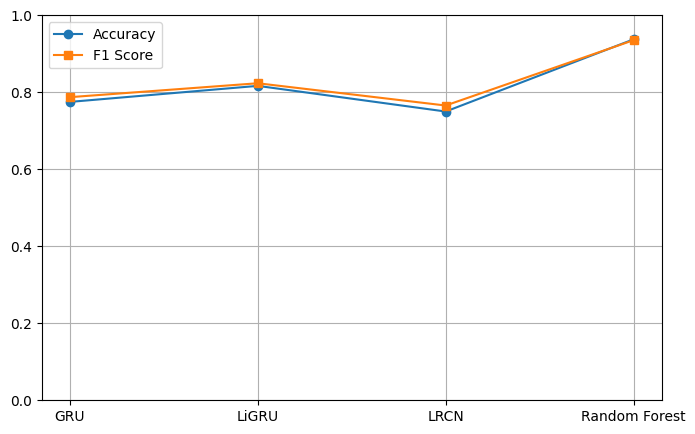

In [ ]:
# =========================================================
# EMPLOYEE PERFORMANCE - FINAL COMPARISON
# GRU vs LiGRU vs LRCN vs RANDOM FOREST
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.layers import Input, Dense, GRU, Dropout, Conv1D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# =============================
# LOAD DATA
# =============================

df = pd.read_excel('/content/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls')

for col in ['EmployeeNumber', 'EmployeeCount', 'StandardHours']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']
y = y - y.min()

# =============================
# SCALE
# =============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# For Deep Learning
X_dl = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

X_train_dl, X_test_dl, y_train, y_test = train_test_split(
    X_dl, y, test_size=0.2, random_state=42, stratify=y)

# For Random Forest
X_train_rf, X_test_rf, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# =============================
# CLASS WEIGHT
# =============================

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train)

class_weights = dict(enumerate(class_weights))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# =============================
# GRU (Basic)
# =============================

inp = Input(shape=(1, X_scaled.shape[1]))
x = GRU(64)(inp)
x = Dropout(0.3)(x)
out = Dense(3, activation='softmax')(x)

gru_model = Model(inp, out)
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_model.fit(X_train_dl, y_train, epochs=40, batch_size=32,
              validation_split=0.2, class_weight=class_weights,
              callbacks=[early_stop], verbose=0)

# =============================
# LiGRU
# =============================

inp2 = Input(shape=(1, X_scaled.shape[1]))
x2 = GRU(64, activation='relu')(inp2)
x2 = Dropout(0.3)(x2)
out2 = Dense(3, activation='softmax')(x2)

ligru_model = Model(inp2, out2)
ligru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ligru_model.fit(X_train_dl, y_train, epochs=40, batch_size=32,
                validation_split=0.2, class_weight=class_weights,
                callbacks=[early_stop], verbose=0)

# =============================
# LRCN (Tuned)
# =============================

inp3 = Input(shape=(1, X_scaled.shape[1]))
x3 = Conv1D(64, 1, activation='relu')(inp3)
x3 = BatchNormalization()(x3)
x3 = GRU(128)(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
out3 = Dense(3, activation='softmax')(x3)

lrcn_model = Model(inp3, out3)
lrcn_model.compile(optimizer=Adam(0.0005),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

lrcn_model.fit(X_train_dl, y_train, epochs=60, batch_size=32,
               validation_split=0.2, class_weight=class_weights,
               callbacks=[early_stop], verbose=0)

# =============================
# RANDOM FOREST (Strong Baseline)
# =============================

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_rf, y_train)

# =============================
# EVALUATION
# =============================

models = {
    "GRU": (gru_model, X_test_dl),
    "LiGRU": (ligru_model, X_test_dl),
    "LRCN": (lrcn_model, X_test_dl)
}

results = []

for name, (model, data) in models.items():
    y_pred = np.argmax(model.predict(data), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append([name, acc, f1])

# Random Forest
rf_pred = rf_model.predict(X_test_rf)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
results.append(["Random Forest", rf_acc, rf_f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
print("\nFinal Comparison Table:\n")
print(results_df)

# =============================
# LINE CHART
# =============================

plt.figure(figsize=(8,5))
plt.plot(results_df["Model"], results_df["Accuracy"], marker='o', label='Accuracy')
plt.plot(results_df["Model"], results_df["F1 Score"], marker='s', label='F1 Score')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()